# Assembly — Final Dataset

Merges all per-document outputs, runs semantic deduplication across the full set, audits coverage against the 100-per-label target, and exports the final assignment CSV. This notebook touches no APIs — it's pure local processing. Fully idempotent: re-run any time as new document notebooks complete.

In [1]:
import sys, statistics, importlib
from pathlib import Path
from collections import Counter

sys.path.insert(0, "..")
import pipeline.core
importlib.reload(pipeline.core)
from pipeline.core import (
    QAPair, LABELS, coverage_audit,
    export_csv, export_detailed,
    load_checkpoint,
)

## Load all available document outputs
Loads whatever checkpoints exist. If a notebook hasn't been run yet, it gets skipped. Re-run this notebook after completing each document to see updated totals.

In [2]:
DOCUMENT_CHECKPOINTS = {
    "Florida Speech": "florida_pairs_filtered",
    "Ivey 2008": "ivey_pairs_filtered",
    "Partnership Letters": "letters_pairs_filtered",
    "Cunningham Essays": "cunningham_pairs_filtered",
    "Notre Dame Lectures": "notredame_pairs_filtered",
    "Gap Fill": "gap_pairs_filtered",
    "Shareholder 2000-2012": "shareholder_pairs_filtered",
}

all_pairs = []
loaded_docs = []

for doc_name, checkpoint_name in DOCUMENT_CHECKPOINTS.items():
    try:
        pairs = load_checkpoint(checkpoint_name)
        all_pairs.extend(pairs)
        loaded_docs.append((doc_name, len(pairs)))
        print(f"   {doc_name}: {len(pairs)} pairs")
    except FileNotFoundError:
        print(f"   {doc_name}: not yet processed")

print(f"\nTotal loaded: {len(all_pairs)} pairs from {len(loaded_docs)} documents")

   Florida Speech: 67 pairs
   Ivey 2008: 25 pairs
   Partnership Letters: 265 pairs
   Cunningham Essays: 316 pairs
   Notre Dame Lectures: 81 pairs
   Gap Fill: 579 pairs
   Shareholder 2000-2012: 653 pairs

Total loaded: 1986 pairs from 7 documents


## Pre-dedup coverage
Where do we stand before removing duplicates? This shows raw contribution from each document and overall label distribution.

In [3]:
print("Combined coverage before dedup:\n")
report = coverage_audit(all_pairs)

Combined coverage before dedup:

  Personal Life             164 pairs ( 8.3%)
    Sublabels hit: early_life, education, mentors, habits, family_influence, personal_values, lifestyle
  Strategy Development      789 pairs (39.7%)
    Sublabels hit: value_investing_framework, margin_of_safety, competitive_moat, business_quality, circle_of_competence, capital_allocation, graham_influence
  Timing                    229 pairs (11.5%)
    Sublabels hit: entry_criteria, exit_criteria, market_valuation, opportunity_cost, patience, price_vs_value, market_cycles
  Risk Management           322 pairs (16.2%)
    Sublabels hit: position_sizing, diversification, leverage_avoidance, permanent_loss, insurance_float, margin_of_safety_risk, concentration
  Adaptability              154 pairs ( 7.8%)
    Sublabels hit: bear_market_behavior, crisis_response, strategy_evolution, mistake_correction, market_regime_shifts, new_opportunities
  Psychology                328 pairs (16.5%)
    Sublabels hit: te

## Semantic deduplication
Uses sentence embeddings to find pairs with near-identical answers across documents. Keeps the higher-scoring pair when duplicates are found. This catches: overlap from sub-chunking within a document, and thematic overlap between documents (e.g. both Florida and Letters discussing the same Buffett principle).

In [4]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

def deduplicate_pairs(pairs, threshold=0.85):
    """Remove semantically similar pairs. Keeps higher-scoring one from each duplicate set."""
    model = SentenceTransformer("all-MiniLM-L6-v2")
    texts = [p.answer for p in pairs]
    print(f"Embedding {len(texts)} answers...")
    embeddings = model.encode(texts, show_progress_bar=True)

    print("Computing similarity matrix...")
    sim_matrix = cosine_similarity(embeddings)

    to_remove = set()
    duplicate_count = 0
    for i in range(len(pairs)):
        if i in to_remove:
            continue
        for j in range(i + 1, len(pairs)):
            if j in to_remove:
                continue
            if sim_matrix[i][j] > threshold:
                score_i = pairs[i].composite_score or 0
                score_j = pairs[j].composite_score or 0
                to_remove.add(j if score_i >= score_j else i)
                duplicate_count += 1

    deduped = [p for idx, p in enumerate(pairs) if idx not in to_remove]
    print(f"\nDuplicates found: {duplicate_count}")
    print(f"Before: {len(pairs)} → After: {len(deduped)} ({len(to_remove)} removed)")
    return deduped

In [5]:
deduped = deduplicate_pairs(all_pairs, threshold=0.85)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding 1986 answers...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Computing similarity matrix...

Duplicates found: 222
Before: 1986 → After: 1773 (213 removed)


## Post-dedup coverage
This is the real coverage audit — against the 100-per-label assignment target. Any label below 100 needs gap-filling from remaining documents (Notre Dame) or by re-running generation with more pairs per chunk.

In [6]:
print("Final coverage after dedup:\n")

for label, lcfg in LABELS.items():
    label_pairs = [p for p in deduped if p.label == label]
    count = len(label_pairs)
    target = lcfg["min_pairs"]
    gap = max(0, target - count)
    status = "✓ PASS" if gap == 0 else f"✗ NEED {gap} MORE"
    sub_counts = Counter(p.sublabel for p in label_pairs if p.sublabel)
    covered = [s for s in lcfg["sublabels"] if sub_counts.get(s, 0) > 0]

    print(f"  {label:25s} {count:3d}/100  {status}")
    if covered:
        print(f"    Sublabels: {', '.join(covered)}")

print(f"\n  Total: {len(deduped)} unique pairs")

Final coverage after dedup:

  Personal Life             134/100  ✓ PASS
    Sublabels: early_life, education, mentors, habits, family_influence, personal_values, lifestyle
  Strategy Development      719/100  ✓ PASS
    Sublabels: value_investing_framework, margin_of_safety, competitive_moat, business_quality, circle_of_competence, capital_allocation, graham_influence
  Timing                    207/100  ✓ PASS
    Sublabels: entry_criteria, exit_criteria, market_valuation, opportunity_cost, patience, price_vs_value, market_cycles
  Risk Management           295/100  ✓ PASS
    Sublabels: position_sizing, diversification, leverage_avoidance, permanent_loss, insurance_float, margin_of_safety_risk, concentration
  Adaptability              126/100  ✓ PASS
    Sublabels: bear_market_behavior, crisis_response, strategy_evolution, mistake_correction, market_regime_shifts, new_opportunities
  Psychology                292/100  ✓ PASS
    Sublabels: temperament, emotional_discipline, contrar

## Score distribution across final set
Overall quality health check. Mean should be above 0.80.

In [7]:
scores = [p.composite_score for p in deduped if p.composite_score]
print(f"Final dataset: {len(deduped)} pairs")
print(f"Score range: {min(scores):.2f} — {max(scores):.2f}")
print(f"Mean:   {statistics.mean(scores):.2f}")
print(f"Median: {statistics.median(scores):.2f}")

Final dataset: 1773 pairs
Score range: 0.70 — 0.94
Mean:   0.83
Median: 0.84


## Export
Two files:
- `buffett_qa_dataset.csv` — the assignment deliverable (Questions, Answers, Label)
- `buffett_qa_detailed.csv` — full metadata for review

If coverage has gaps, address them first, then re-run from cell 4 onward.

In [8]:
export_csv(deduped, Path("../output/buffett_qa_dataset.csv"))
export_detailed(deduped, Path("../output/buffett_qa_detailed.csv"))

Exported 1773 pairs to ..\output\buffett_qa_dataset.csv
  Strategy Development: 719
  Risk Management: 295
  Psychology: 292
  Timing: 207
  Personal Life: 134
  Adaptability: 126
Detailed export: ..\output\buffett_qa_detailed.csv


In [9]:
# Per-document contribution to the final set
source_counts = Counter(p.source_file for p in deduped)
print("Contribution by document:\n")
for source, count in source_counts.most_common():
    print(f"  {source:35s} {count:3d} pairs")

Contribution by document:

  shareholder_letters_2000_2012.pdf   576 pairs
  cunningham_essays.pdf               495 pairs
  partnership_letters.pdf             402 pairs
  notredame_lectures.pdf              146 pairs
  florida_speech.pdf                  121 pairs
  ivey_2008.pdf                        33 pairs


In [10]:
# Best pair per label — final quality showcase
label_counts = Counter(p.label for p in deduped)
print(f"FINAL DATASET: {len(deduped)} pairs across {len(label_counts)} labels\n")
for label, count in label_counts.most_common():
    best = max((p for p in deduped if p.label == label), key=lambda p: p.composite_score)
    print(f"── {label} ({count} pairs, best: {best.composite_score:.2f}) ──")
    print(f"  Q: {best.question}")
    print(f"  A: {best.answer[:300]}")
    print()

FINAL DATASET: 1773 pairs across 6 labels

── Strategy Development (719 pairs, best: 0.94) ──
  Q: How does Warren Buffett's analysis of the newspaper industry's historical 'economic heaven' and its subsequent decline illustrate the interconnected application of his core principles of competitive moat, business quality erosion, and the margin of safety, and what does this reveal about the dynamic nature of value investing?
  A: Buffett's analysis shows that the newspaper industry's historical strength was a perfect example of a competitive moat created by a 'circularity' where high circulation attracted advertisers, and more ads/news attracted readers, leading to a monopoly in one-paper cities. This moat, as he notes, allo

── Risk Management (295 pairs, best: 0.94) ──
  Q: In his analysis of municipal bond insurance, how does Warren Buffett connect the historical rarity of tax-exempt defaults to a future, unappreciated risk, and what specific behavioral shift does he predict that tran

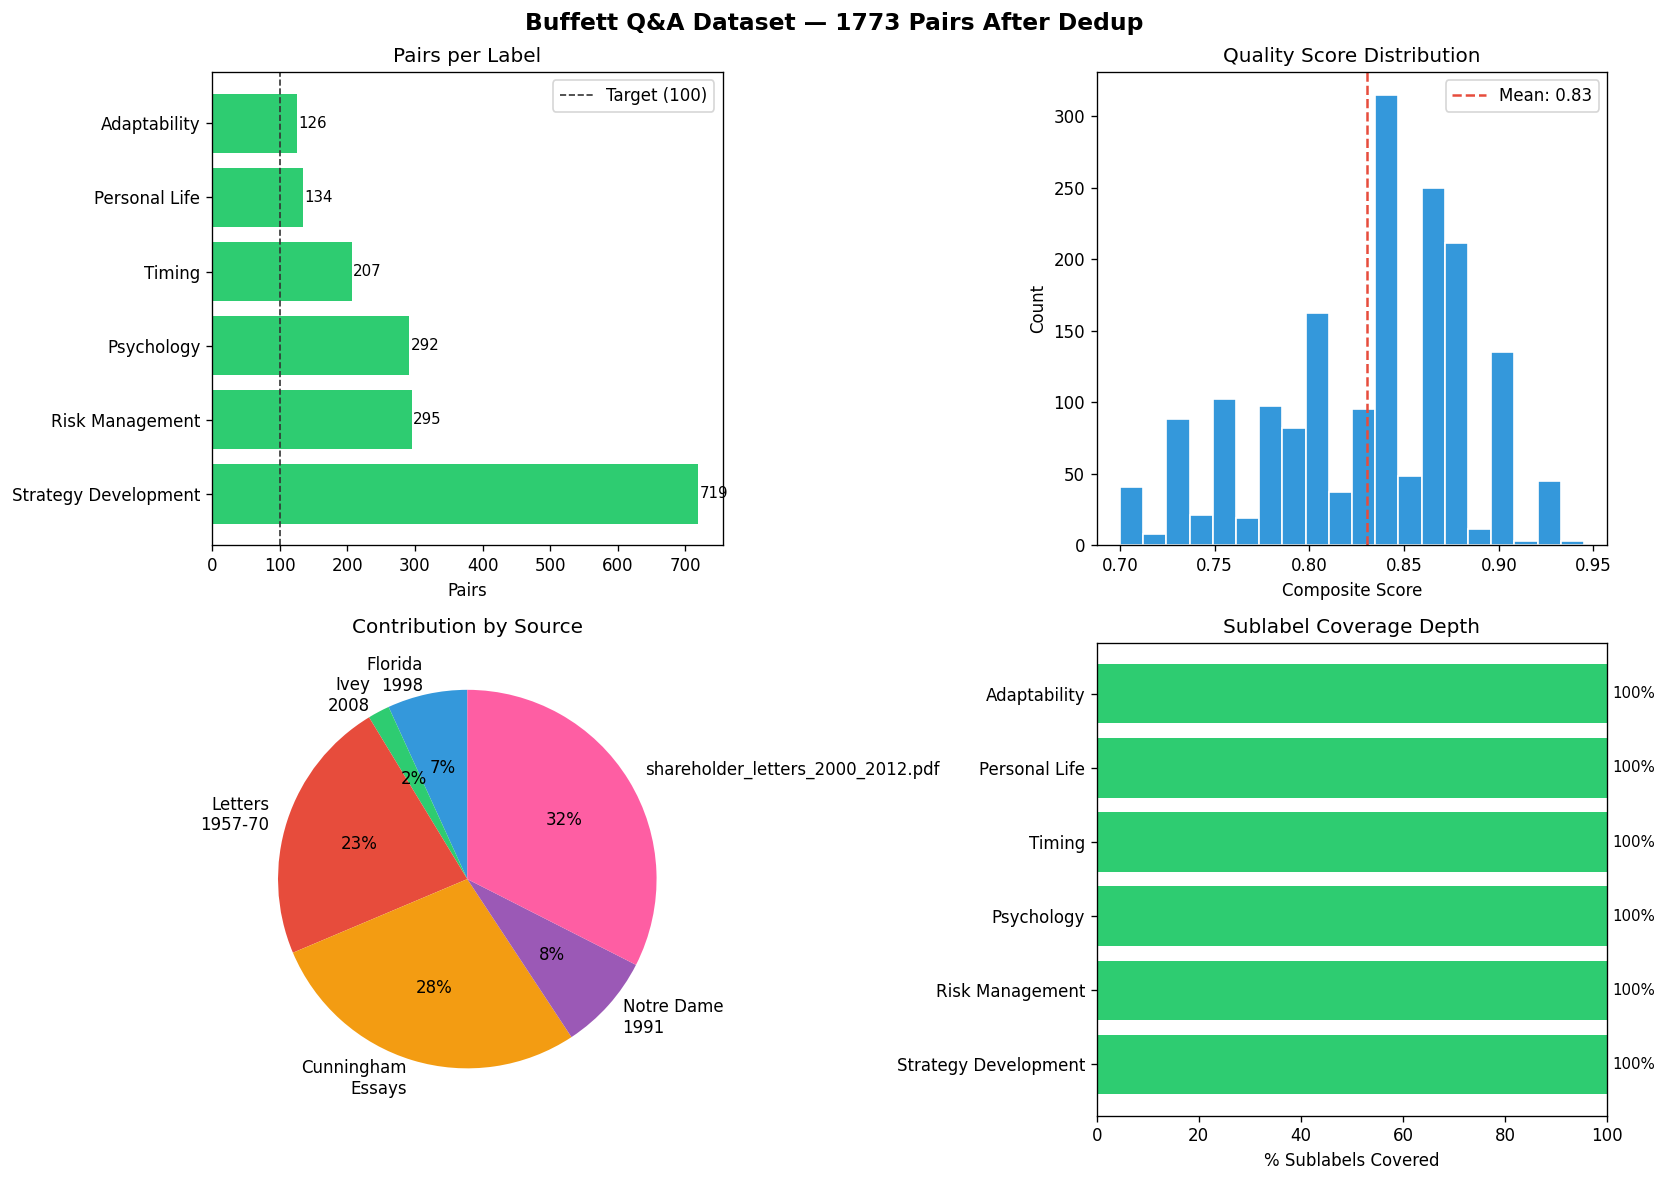

Saved to output/dataset_summary.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['figure.dpi'] = 120

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Buffett Q&A Dataset — {len(deduped)} Pairs After Dedup', fontsize=14, fontweight='bold')

# 1. Label distribution with 100-target line
ax1 = axes[0, 0]
label_counts = Counter(p.label for p in deduped)
labels = [l for l, _ in label_counts.most_common()]
counts = [label_counts[l] for l in labels]
colors = ['#2ecc71' if c >= 100 else '#e74c3c' for c in counts]
bars = ax1.barh(labels, counts, color=colors)
ax1.axvline(x=100, color='#333', linestyle='--', linewidth=1, label='Target (100)')
ax1.set_xlabel('Pairs')
ax1.set_title('Pairs per Label')
ax1.legend()
for bar, count in zip(bars, counts):
    ax1.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, str(count), va='center', fontsize=9)

# 2. Score distribution
ax2 = axes[0, 1]
scores = [p.composite_score for p in deduped if p.composite_score]
ax2.hist(scores, bins=20, color='#3498db', edgecolor='white')
ax2.axvline(x=statistics.mean(scores), color='#e74c3c', linestyle='--', label=f'Mean: {statistics.mean(scores):.2f}')
ax2.set_xlabel('Composite Score')
ax2.set_ylabel('Count')
ax2.set_title('Quality Score Distribution')
ax2.legend()

# 3. Source contribution
ax3 = axes[1, 0]
source_counts = Counter(p.source_file for p in deduped)
source_names = {
    'partnership_letters.pdf': 'Letters\n1957-70',
    'cunningham_essays.pdf': 'Cunningham\nEssays',
    'florida_speech.pdf': 'Florida\n1998',
    'ivey_2008.pdf': 'Ivey\n2008',
    'notredame_lectures.pdf': 'Notre Dame\n1991',
}
src_labels = [source_names.get(s, s) for s in source_counts.keys()]
src_values = list(source_counts.values())
ax3.pie(src_values, labels=src_labels, autopct='%1.0f%%', startangle=90,
        colors=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', "#FE5EA3"])
ax3.set_title('Contribution by Source')

# 4. Sublabel coverage heatmap
ax4 = axes[1, 1]
label_order = [l for l, _ in label_counts.most_common()]
sublabel_data = {}
for label in label_order:
    lcfg = LABELS[label]
    label_pairs = [p for p in deduped if p.label == label]
    sub_counts = Counter(p.sublabel for p in label_pairs if p.sublabel)
    covered = sum(1 for s in lcfg["sublabels"] if sub_counts.get(s, 0) > 0)
    total = len(lcfg["sublabels"])
    sublabel_data[label] = covered / total if total > 0 else 0

sub_labels = list(sublabel_data.keys())
sub_values = list(sublabel_data.values())
sub_colors = ['#2ecc71' if v > 0.7 else '#f39c12' if v > 0.4 else '#e74c3c' for v in sub_values]
bars4 = ax4.barh(sub_labels, [v * 100 for v in sub_values], color=sub_colors)
ax4.set_xlabel('% Sublabels Covered')
ax4.set_title('Sublabel Coverage Depth')
ax4.set_xlim(0, 100)
for bar, val in zip(bars4, sub_values):
    ax4.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{val:.0%}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../output/dataset_summary.png', bbox_inches='tight')
plt.show()
print("Saved to output/dataset_summary.png")

## Interactive Spot Check
Browse pairs by label. Run the cell, type a label name or number to filter, then step through pairs one at a time. Type `next` to see another, `skip` to jump ahead 10, or `quit` to stop.

In [12]:
def spot_check(pairs):
    label_list = sorted(set(p.label for p in pairs))

    print("Available labels:\n")
    for i, label in enumerate(label_list):
        count = sum(1 for p in pairs if p.label == label)
        print(f"  [{i}] {label} ({count} pairs)")

    choice = input("\nEnter label number or name: ").strip()

    # Resolve choice
    if choice.isdigit() and int(choice) < len(label_list):
        selected = label_list[int(choice)]
    else:
        matches = [l for l in label_list if choice.lower() in l.lower()]
        selected = matches[0] if matches else None

    if not selected:
        print("Label not found.")
        return

    label_pairs = sorted(
        [p for p in pairs if p.label == selected],
        key=lambda p: -(p.composite_score or 0)
    )
    print(f"\n{'='*70}")
    print(f"{selected}: {len(label_pairs)} pairs (sorted best → worst)")
    print(f"{'='*70}")

    i = 0
    while i < len(label_pairs):
        p = label_pairs[i]
        score = f"{p.composite_score:.2f}" if p.composite_score else "N/A"
        print(f"\n[{i+1}/{len(label_pairs)}] Score: {score} | Source: {p.source_file} | Sublabel: {p.sublabel or 'N/A'}")
        print(f"  Q: {p.question}")
        print(f"  A: {p.answer}")
        if p.composite_score:
            print(f"  Breakdown: ground={p.groundedness_score:.2f} fit={p.label_fit_score:.2f} "
                  f"rich={p.richness_score:.2f} novel={p.novelty_score:.2f}")

        cmd = input("\n[Enter]=next | [s]=skip 10 | [q]=quit | [r]=restart: ").strip().lower()
        if cmd == 'q':
            break
        elif cmd == 's':
            i += 10
        elif cmd == 'r':
            spot_check(pairs)
            return
        else:
            i += 1

    print("\nEnd of pairs for this label.")

spot_check(deduped)

Available labels:

  [0] Adaptability (126 pairs)
  [1] Personal Life (134 pairs)
  [2] Psychology (292 pairs)
  [3] Risk Management (295 pairs)
  [4] Strategy Development (719 pairs)
  [5] Timing (207 pairs)

Adaptability: 126 pairs (sorted best → worst)

[1/126] Score: 0.91 | Source: shareholder_letters_2000_2012.pdf | Sublabel: market_regime_shifts
  Q: Analyze how Warren Buffett's approach to GEICO demonstrates his adaptability in responding to both adverse market conditions and new opportunities, specifically comparing the strategic withdrawal from and subsequent re-entry into New Jersey. What does this sequence reveal about his principles of capital allocation, patience, and the reassessment of intrinsic value in changing regulatory environments?
  A: Buffett's adaptability is shown through GEICO's strategic withdrawal from New Jersey in 1976 and its re-entry in 2003, actions driven by a disciplined assessment of market conditions. In the adverse condition of a hostile regulatory

In [13]:
import sys, statistics, importlib
from pathlib import Path
from collections import Counter

sys.path.insert(0, "..")
import pipeline.core
importlib.reload(pipeline.core)
from pipeline.core import QAPair, LABELS, coverage_audit, export_csv, export_detailed, load_checkpoint

CHECKPOINTS = {
    "Florida Speech": "florida_pairs_filtered",
    "Ivey 2008": "ivey_pairs_filtered",
    "Partnership Letters": "letters_pairs_filtered",
    "Cunningham Essays": "cunningham_pairs_filtered",
    "Notre Dame": "notredame_pairs_filtered",
    "Gap Fill": "gap_pairs_filtered",
}

all_pairs = []
for name, ckpt in CHECKPOINTS.items():
    try:
        pairs = load_checkpoint(ckpt)
        all_pairs.extend(pairs)
        print(f"  ✓ {name}: {len(pairs)} pairs")
    except FileNotFoundError:
        print(f"  ✗ {name}: not found")

# Quick dedup by question text to avoid rerunning full semantic dedup for analysis
seen = set()
deduped = []
for p in all_pairs:
    key = p.question.strip().lower()
    if key not in seen:
        seen.add(key)
        deduped.append(p)

print(f"\nLoaded: {len(all_pairs)} raw → {len(deduped)} after text dedup")

  ✓ Florida Speech: 67 pairs
  ✓ Ivey 2008: 25 pairs
  ✓ Partnership Letters: 265 pairs
  ✓ Cunningham Essays: 316 pairs
  ✓ Notre Dame: 81 pairs
  ✓ Gap Fill: 579 pairs

Loaded: 1333 raw → 1310 after text dedup


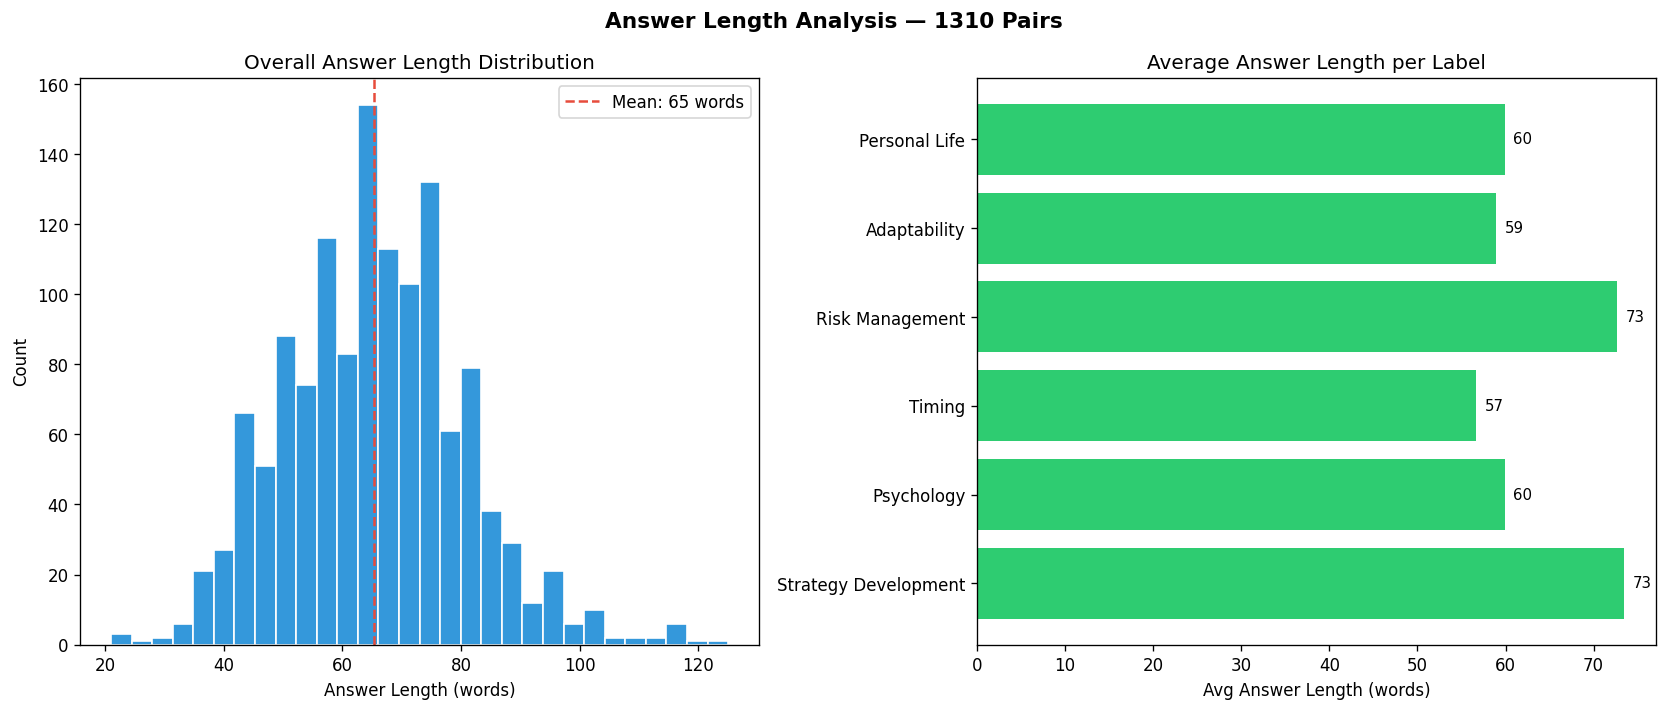

In [14]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Answer Length Analysis — {len(deduped)} Pairs', fontsize=13, fontweight='bold')

# 1. Histogram of answer lengths across entire dataset
ax1 = axes[0]
all_lengths = [len(p.answer.split()) for p in deduped]
ax1.hist(all_lengths, bins=30, color='#3498db', edgecolor='white')
ax1.axvline(np.mean(all_lengths), color='#e74c3c', linestyle='--', label=f'Mean: {np.mean(all_lengths):.0f} words')
ax1.set_xlabel('Answer Length (words)')
ax1.set_ylabel('Count')
ax1.set_title('Overall Answer Length Distribution')
ax1.legend()

# 2. Average answer length per label
ax2 = axes[1]
label_order = [l for l, _ in Counter(p.label for p in deduped).most_common()]
avg_lengths = [np.mean([len(p.answer.split()) for p in deduped if p.label == l]) for l in label_order]
bars = ax2.barh(label_order, avg_lengths, color='#2ecc71')
ax2.set_xlabel('Avg Answer Length (words)')
ax2.set_title('Average Answer Length per Label')
for bar, val in zip(bars, avg_lengths):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../output/answer_length_analysis.png', bbox_inches='tight')
plt.show()